# Chapter 8: The Delphi Room
Anonymous feedback can reduce disagreement. This simulation asks whether that
also removes error. Synthetic experts are illustrative, not RAND participants.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(8); truth=100.; views=truth+15+rng.normal(0,18,30); rounds=[views.copy()]
for _ in range(4):
    views=.6*views+.4*np.median(views)+rng.normal(0,1,30); rounds.append(views.copy())

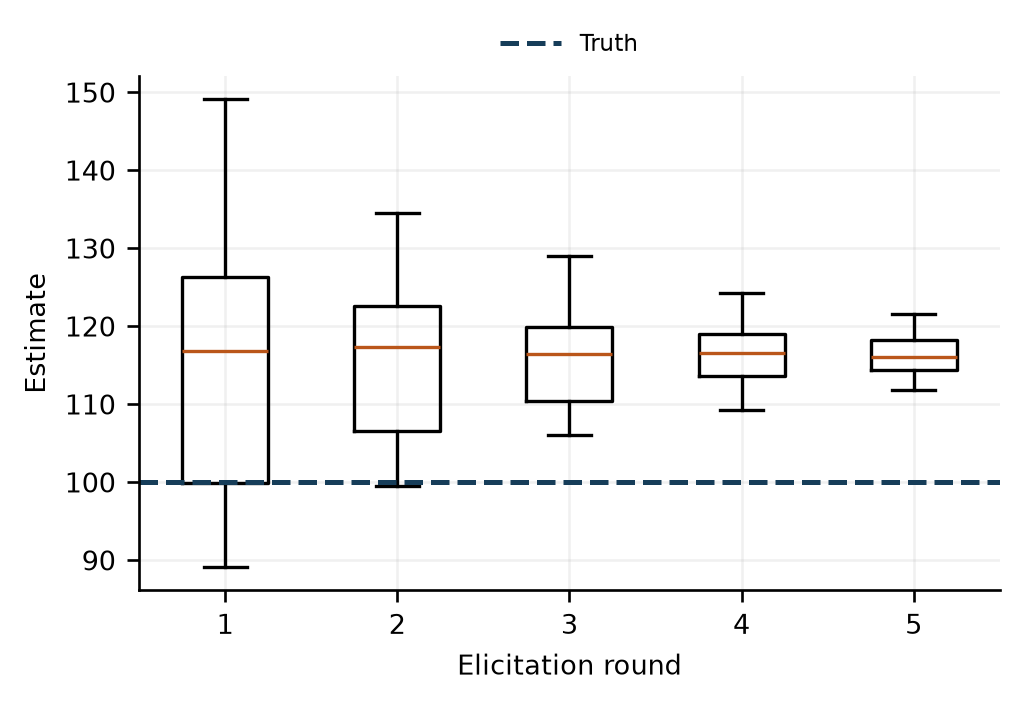

In [2]:
plt.figure(); plt.boxplot(rounds,tick_labels=[str(i+1) for i in range(5)]); plt.axhline(truth,ls='--',label='Truth'); plt.xlabel('Elicitation round'); plt.ylabel('Estimate'); plt.legend()
save(8,1,'Feedback concentrates expert estimates','Synthetic experts begin with shared positive bias. Anonymous median feedback narrows their spread.','## Delphi in the Wild')

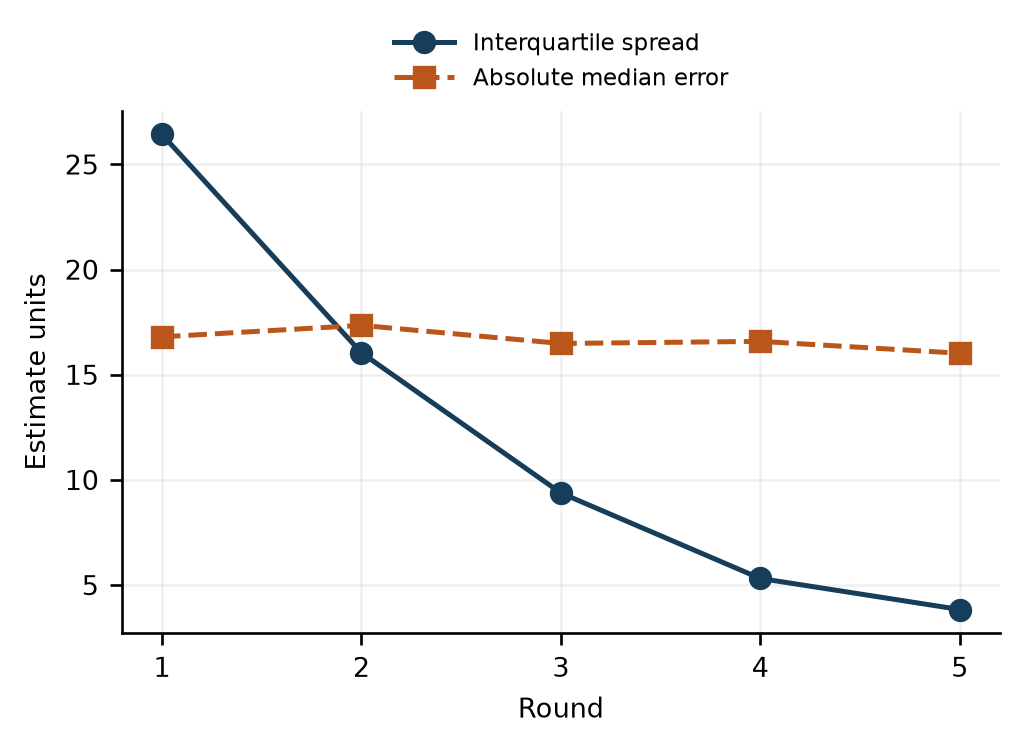

In [3]:
spread=[np.subtract(*np.percentile(x,[75,25])) for x in rounds]; error=[abs(np.median(x)-truth) for x in rounds]
plt.figure(); plt.plot(range(1,6),spread,'o-',label='Interquartile spread'); plt.plot(range(1,6),error,'s--',label='Absolute median error'); plt.xticks(range(1,6)); plt.xlabel('Round'); plt.ylabel('Estimate units'); plt.legend()
save(8,2,'Consensus is not calibration','The same synthetic rounds: declining disagreement can coexist with persistent bias in the group estimate.','## The Cognitive Problem Delphi Did Not Solve')

## Independent information matters more than the number of voices
Compare repeated groups with a common error component to independent groups.

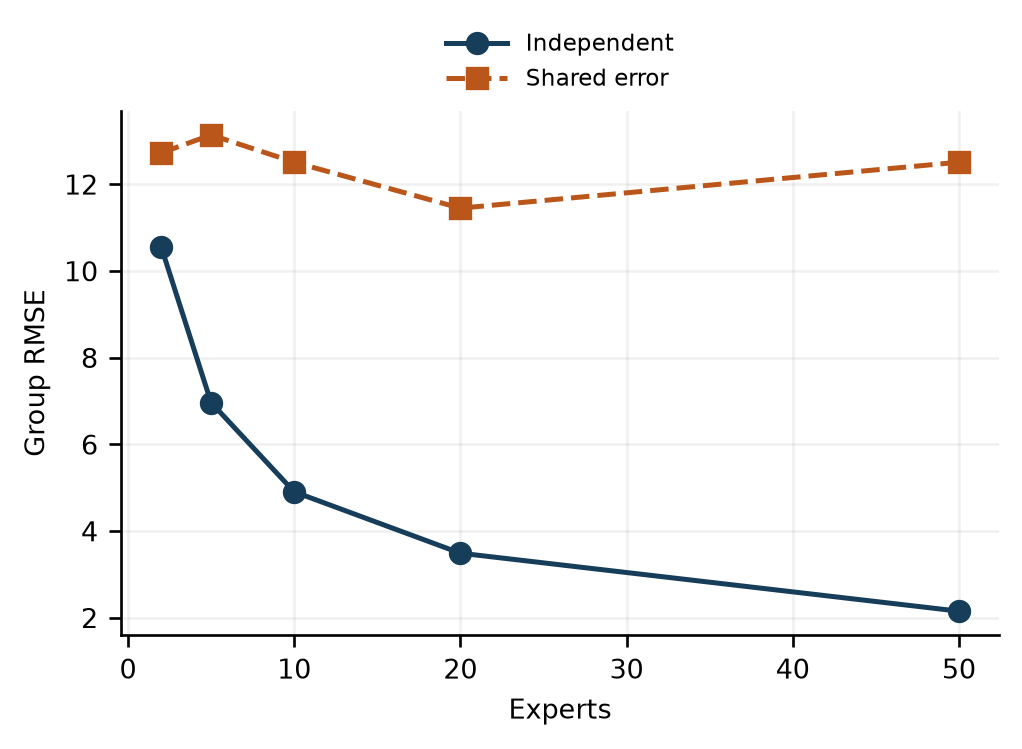

Forecast value added relative to first-round median: 0.7800225114365844


In [4]:
sizes=[2,5,10,20,50]; independent=[]; shared=[]
for n in sizes:
    noise=rng.normal(0,15,(500,n)); common=rng.normal(0,12,(500,1))
    independent.append(np.sqrt(np.mean(noise.mean(axis=1)**2)))
    shared.append(np.sqrt(np.mean((.6*noise+common).mean(axis=1)**2)))
plt.figure(); plt.plot(sizes,independent,'o-',label='Independent'); plt.plot(sizes,shared,'s--',label='Shared error'); plt.xlabel('Experts'); plt.ylabel('Group RMSE'); plt.legend()
save(8,3,'A larger panel cannot average away shared error','Repeated synthetic panels with equal individual error variance: 15² = 9² + 12². Shared error persists even when idiosyncratic errors average out.','## The Full Machinery')
print('Forecast value added relative to first-round median:',error[0]-error[-1])

## Limits and exercise
Replace shared bias with independent private evidence and rerun. Record initial
forecasts before discussion so FVA is measurable. Elicited quartiles alone do
not identify a full probability distribution; a family assumption is required.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV question,expert,round,estimate,actual; one estimate per question/expert/round. round is a positive integer, estimates share units, actual is finite for CLI scoring and identical across rows for the same question; retain unresolved blank actuals separately. Keep rationale and evidence in a linked qualitative record.

Minimal **format illustration**, not sufficient training data:

```csv
question,expert,round,estimate,actual
Q1,E1,1,100,110
Q1,E2,1,120,110
```

## Explain the mechanism

Delphi structures communication so experts can revise without public pressure. Its value depends on better evidence and reasoning, not merely on getting numbers closer together. A group can become uniformly wrong.

## Work through the arithmetic

First-round estimates [80,100,140] have median 100. Final estimates [110,112,114] have median 112. If truth is 100, median absolute error rises from 0 to 12 despite lower spread; forecast value added, initial loss minus final loss, is -12.

## Adapt the lesson to reader data

Replace the generated expert views with actual round records. Do not replace their missing outcomes with the simulation truth=100. Summarize the same experts separately from the full panel if participants leave. Store reasons for revisions because a numerical movement alone cannot show whether evidence improved.

For this chapter, settle these questions before fitting: What question and common units will every expert answer? What independent evidence does each have? How many rounds are justified? When will actual outcomes resolve?

## Interpret the actual lesson outputs

The lesson’s feedback rule pulls estimates toward a median while shared bias persists. Its original shared-error experiment adds common variance 144 to individual variance 225, so total marginal variance rises to 369; it does not isolate correlation at fixed individual variance. Check the current caption if the lesson has been revised.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `question,round,n,median,iqr,absolute_error`.
- `summary.json`: `forecast_value_added,questions,rounds` plus method, interpretation, assumptions, not_done and status.

The adapter requires complete resolved actuals and compares round medians. Keep unresolved elicitation records in a separate journal until resolution. It does not solicit experts, authenticate independence or estimate a full opinion distribution.

## Decide what the evidence supports

Falling interquartile range measures agreement. It does not measure calibration or accuracy. Attrition can make later consensus appear stronger. Elicited quartiles alone do not determine a full probability distribution.

Without actuals, report agreement and unresolved status but no accuracy score. With one expert, report an expert judgment rather than a Delphi panel. Without independent evidence, explain common-source dependence and seek external information.

The applied deliverable must make these items inspectable: `results.csv` columns: `question,round,n,median,iqr,absolute_error`; `summary.json` keys: `forecast_value_added,questions,rounds` plus method, interpretation, assumptions, not_done and status. Return anonymized round tables, medians/spreads, rationale changes, dissenting evidence, stopping reason and resolved-question first-versus-final losses where available.

## Three exercises with worked solutions

### Exercise 1

Initial error 20, final error 12: forecast value added?

**Worked solution.** 20-12=8 units of absolute-error improvement.

### Exercise 2

Panel spread halves but outcomes are unresolved. What can be concluded?

**Worked solution.** Agreement increased; accuracy and calibration remain unknown.

### Exercise 3

Ten respondents repeat the same consultant report. Are there ten independent sources?

**Worked solution.** No. Their shared source creates dependence; disclose it and seek evidence with a different failure mechanism.

## Business-reader application

Use this request with the skill:

> Use chapter 8 to analyze expert_rounds.csv, distinguish consensus from accuracy, retain dissent and evaluate whether later rounds improved resolved forecasts.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch08.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch08.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(8, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch08-workshop-results.csv', index=False)
_ = (workshop_output/'ch08-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Delphi round comparison: median, spread and forecast value added
Status: passed

Interpretation: Across 8 questions the final-round median beat the first-round median on 8. Positive forecast value added means the panel moved toward the outcome; convergence alone is not accuracy. Check whether panel membership changed between rounds.

Assumptions:
  - Each question has one resolved outcome
  - Round numbers are comparable across questions
  - Estimates in a round were made before that round's feedback
Not done:
  - No test of whether shared information drove the convergence
  - No weighting of experts by past accuracy

Evidence:
  forecast_value_added: <8 entries>
  questions: 8
  rounds: 3

Table: 24 rows, columns ['question', 'round', 'n', 'median', 'iqr', 'absolute_error']

 question  round  n  median    iqr  absolute_error
        0      1 12 106.586 33.250           6.586
        0      2 12 104.610 23.275           4.610
        0      3 12 103.227 16.293           3.227
 

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Did the experts estimate independently before seeing each other, and is the first round preserved?**
   A bad answer looks like this: Convergence after discussion is agreement, not accuracy, unless the initial spread is kept and compared.

2. **What did the panel know that the base rate did not, and is the change in the median explained by it?**
   A bad answer looks like this: A median that moved without new information moved for social reasons.

3. **Will the outcome be scored against the final round, and by whom?**
   A bad answer looks like this: A Delphi with no resolution date teaches nothing about the panel.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).